# 2. Summary Statistic Sensitivity Analysis

Which summary stats are informative about which model parameters?
Which stats track learning across sessions? Which are redundant?

**Part A**: Single-session param-stat correlations — sample params from prior,
simulate, compute stats, correlate.

**Part B**: Multi-session trajectory sensitivity — generate synthetic animals
with known eta trajectories, compute stats per session, correlate with
session index and true eta.

In [1]:
# =============================================================================
# IMPORTS AND SETUP
# =============================================================================

import sys
import os

sys.path.append(os.path.abspath(".."))

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr

from Models.BE_core import BEParams, BEState, BEModel
from Data.structures import (
    sample_stimuli, stimulus_to_category,
    load_session_csv, load_animal, load_experiment,
    AnimalData, ExperimentData,
    generate_synthetic_animal,
    param_trajectory_naive_to_expert,
)
from Analysis.summary_stats import (
    compute_summary_stats,
    compute_summary_stats_per_session,
    list_available_stats,
    get_stat_names_expanded,
)

# Print all available stats
ALL_STATS = list_available_stats()
expanded_names = get_stat_names_expanded(ALL_STATS)
n_stats = len(expanded_names)

print(f'Available summary stat groups ({len(ALL_STATS)}):')
print('-' * 50)
for s in ALL_STATS:
    n = len(get_stat_names_expanded([s]))
    print(f'  {s:30s} -> {n:3d} feature(s)')
print('-' * 50)
print(f'Total expanded features: {n_stats}')

PARAM_NAMES = ['sigma_percep', 'A_repulsion', 'eta_learning', 'eta_relax']
print('\nSetup complete.')


Available summary stat groups (19):
--------------------------------------------------
  accuracy                       ->   1 feature(s)
  psychometric                   ->   4 feature(s)
  recency                        ->   1 feature(s)
  win_stay                       ->   1 feature(s)
  win_stay_rate                  ->   1 feature(s)
  lose_shift                     ->   1 feature(s)
  choice_autocorr                ->   1 feature(s)
  side_bias                      ->   1 feature(s)
  stimulus_sensitivity           ->   1 feature(s)
  choice_entropy                 ->   1 feature(s)
  perseveration                  ->   1 feature(s)
  logistic_history               ->   8 feature(s)
  hard_easy_ratio                ->   1 feature(s)
  hard_accuracy                  ->   1 feature(s)
  easy_accuracy                  ->   1 feature(s)
  conditional_psychometric       ->  32 feature(s)
  update_matrix                  ->  64 feature(s)
  binned_accuracy                ->   8 featur

## Part A: Single-Session Param-Stat Correlations

For each simulation: sample params from uniform prior over bounds,
simulate 300 trials, compute all candidate stats. Then compute
Spearman correlations between each param and each stat.

In [2]:
# --- Configuration ---
N_SAMPLES = 3000   # Number of simulations (increase for smoother results)
N_TRIALS = 300
BURN_IN = 100
SEED = 42

In [ ]:
# --- Run simulations ---
rng = np.random.default_rng(SEED)
bounds = BEParams.get_bounds()
expanded_names = get_stat_names_expanded(ALL_STATS)
n_stats = len(expanded_names)

param_values = np.empty((N_SAMPLES, 4))
stat_values = np.empty((N_SAMPLES, n_stats))

print(f"Simulating {N_SAMPLES} sessions with {n_stats} stats each...")
t0 = time.time()
n_failed = 0

for i in range(N_SAMPLES):
    if i % 500 == 0 and i > 0:
        elapsed = time.time() - t0
        rate = i / elapsed
        print(f"  {i}/{N_SAMPLES} ({elapsed:.0f}s, ~{(N_SAMPLES-i)/rate:.0f}s left)")
    
    # Sample params uniformly from bounds
    params = BEParams(
        sigma_percep=rng.uniform(*bounds['sigma_percep']),
        A_repulsion=rng.uniform(*bounds['A_repulsion']),
        eta_learning=rng.uniform(*bounds['eta_learning']),
        eta_relax=rng.uniform(*bounds['eta_relax']),
    )
    param_values[i] = params.to_array()
    
    # Simulate with burn-in
    state = BEState.initial_uniform()
    burn_stim = rng.uniform(-1.0, 1.0, BURN_IN)
    burn_cats = stimulus_to_category(burn_stim)
    _, _, state, _ = BEModel.simulate_session(params, state, burn_stim, burn_cats, rng)
    
    stimuli = sample_stimuli(N_TRIALS, 'Uniform', rng)
    categories = stimulus_to_category(stimuli)
    choices, _, _, _ = BEModel.simulate_session(params, state, stimuli, categories, rng)
    
    try:
        stats = compute_summary_stats(
            choices, stimuli, categories,
            stat_names=ALL_STATS, return_dict=False,
        )
        if len(stats) == n_stats:
            stat_values[i] = stats
        else:
            stat_values[i] = np.nan
            n_failed += 1
    except Exception:
        stat_values[i] = np.nan
        n_failed += 1

elapsed = time.time() - t0
valid_mask = ~np.any(np.isnan(stat_values), axis=1)
param_values_clean = param_values[valid_mask]
stat_values_clean = stat_values[valid_mask]
print(f"Done in {elapsed:.1f}s. {valid_mask.sum()}/{N_SAMPLES} valid ({n_failed} failures)")

Simulating 3000 sessions with 137 stats each...


In [4]:
# --- Compute Spearman correlations: params vs stats ---
param_stat_corr = np.empty((4, n_stats))
param_stat_pval = np.empty((4, n_stats))

for p in range(4):
    for s in range(n_stats):
        sv = stat_values_clean[:, s]
        vm = ~np.isnan(sv)
        if vm.sum() < 30:
            param_stat_corr[p, s] = np.nan
            param_stat_pval[p, s] = np.nan
        else:
            rho, pval = spearmanr(param_values_clean[vm, p], sv[vm])
            param_stat_corr[p, s] = rho
            param_stat_pval[p, s] = pval

# Inter-stat correlations
stat_stat_corr = np.empty((n_stats, n_stats))
for i in range(n_stats):
    for j in range(n_stats):
        vi, vj = stat_values_clean[:, i], stat_values_clean[:, j]
        vm = ~np.isnan(vi) & ~np.isnan(vj)
        if vm.sum() < 30:
            stat_stat_corr[i, j] = np.nan
        else:
            rho, _ = spearmanr(vi[vm], vj[vm])
            stat_stat_corr[i, j] = rho

print("Correlations computed.")

Correlations computed.


### Param-Stat Correlation Heatmap

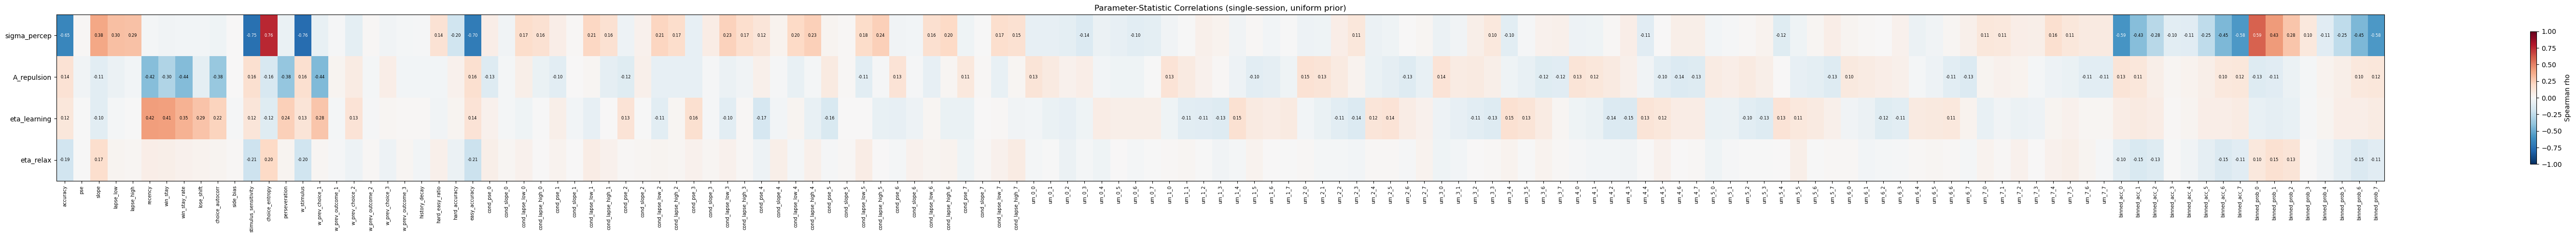

In [5]:
fig, ax = plt.subplots(figsize=(max(14, n_stats * 0.45), 5))

im = ax.imshow(param_stat_corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(4))
ax.set_yticklabels(PARAM_NAMES)
ax.set_xticks(range(n_stats))
ax.set_xticklabels(expanded_names, rotation=90, fontsize=7)

for i in range(4):
    for j in range(n_stats):
        val = param_stat_corr[i, j]
        if not np.isnan(val) and abs(val) > 0.1:
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman rho')
ax.set_title('Parameter-Statistic Correlations (single-session, uniform prior)')
plt.tight_layout()
plt.show()

### Inter-Stat Redundancy Heatmap

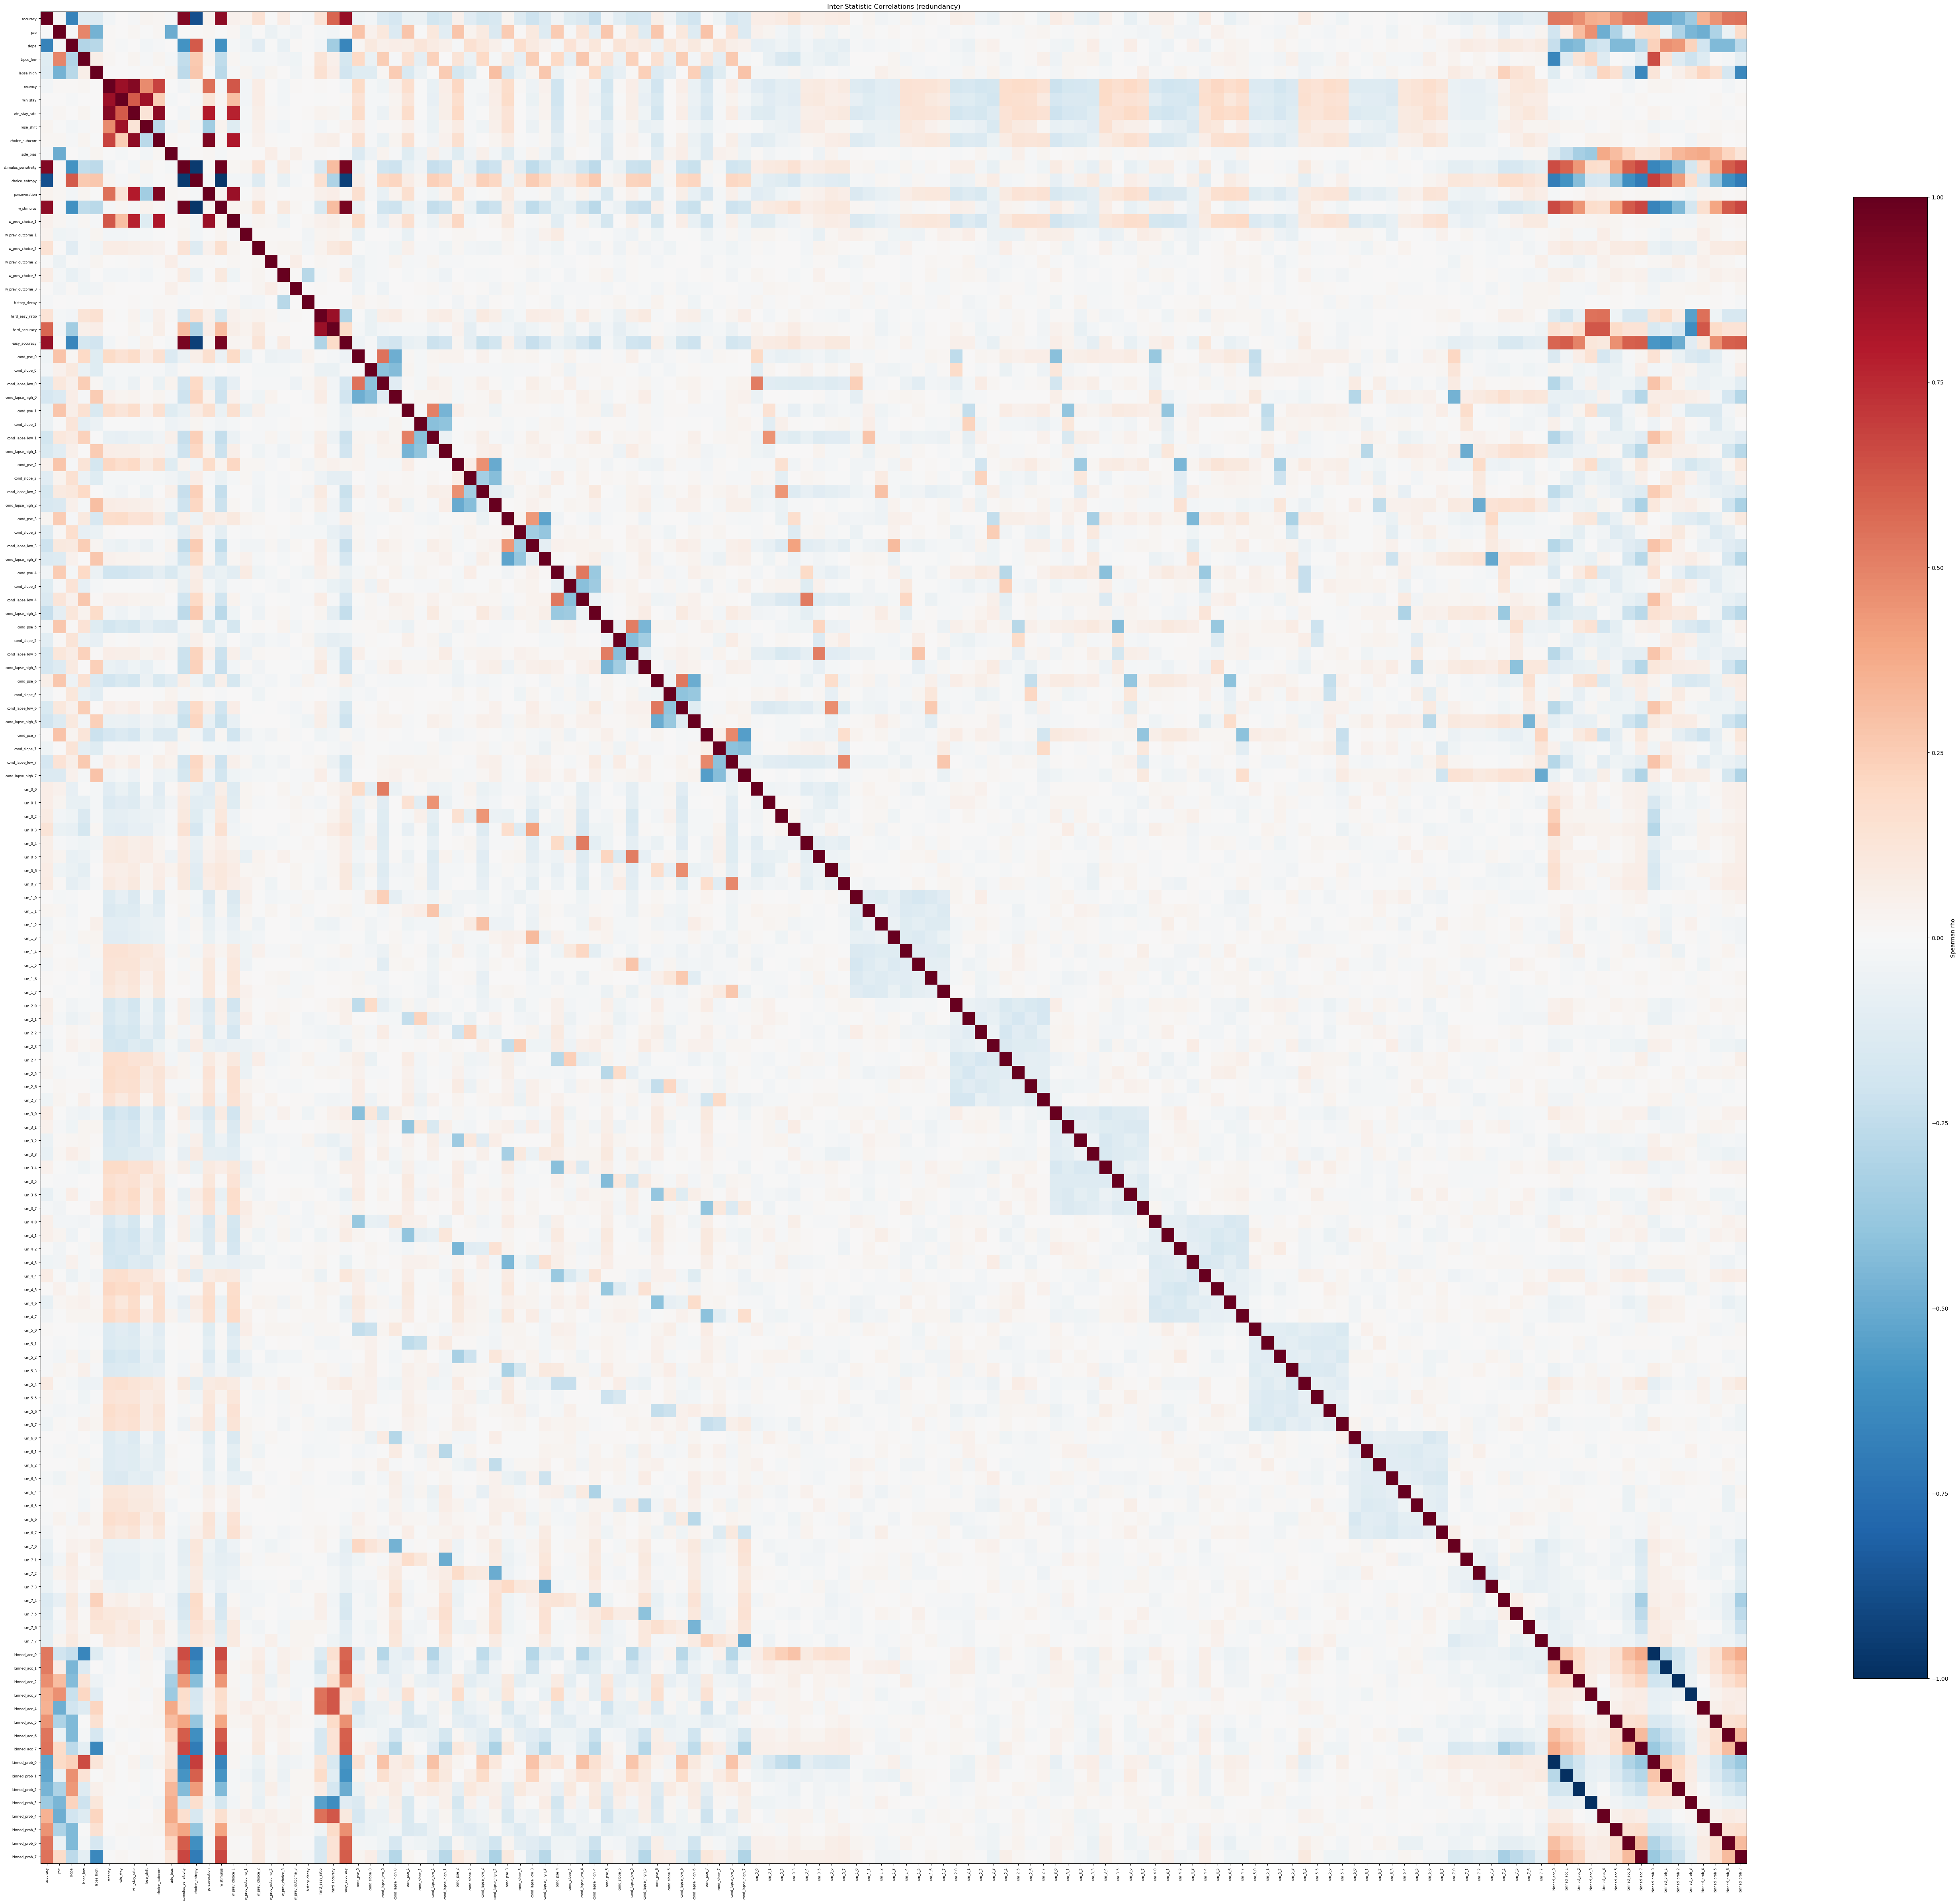

In [6]:
fig, ax = plt.subplots(figsize=(max(12, n_stats * 0.4), max(10, n_stats * 0.35)))

im = ax.imshow(stat_stat_corr, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_stats))
ax.set_xticklabels(expanded_names, rotation=90, fontsize=6)
ax.set_yticks(range(n_stats))
ax.set_yticklabels(expanded_names, fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman rho')
ax.set_title('Inter-Statistic Correlations (redundancy)')
plt.tight_layout()
plt.show()

### Per-Parameter Discriminability

For each parameter: which stats have strong correlation with that parameter
but weak correlation with others? Stars mark uniquely informative stats.

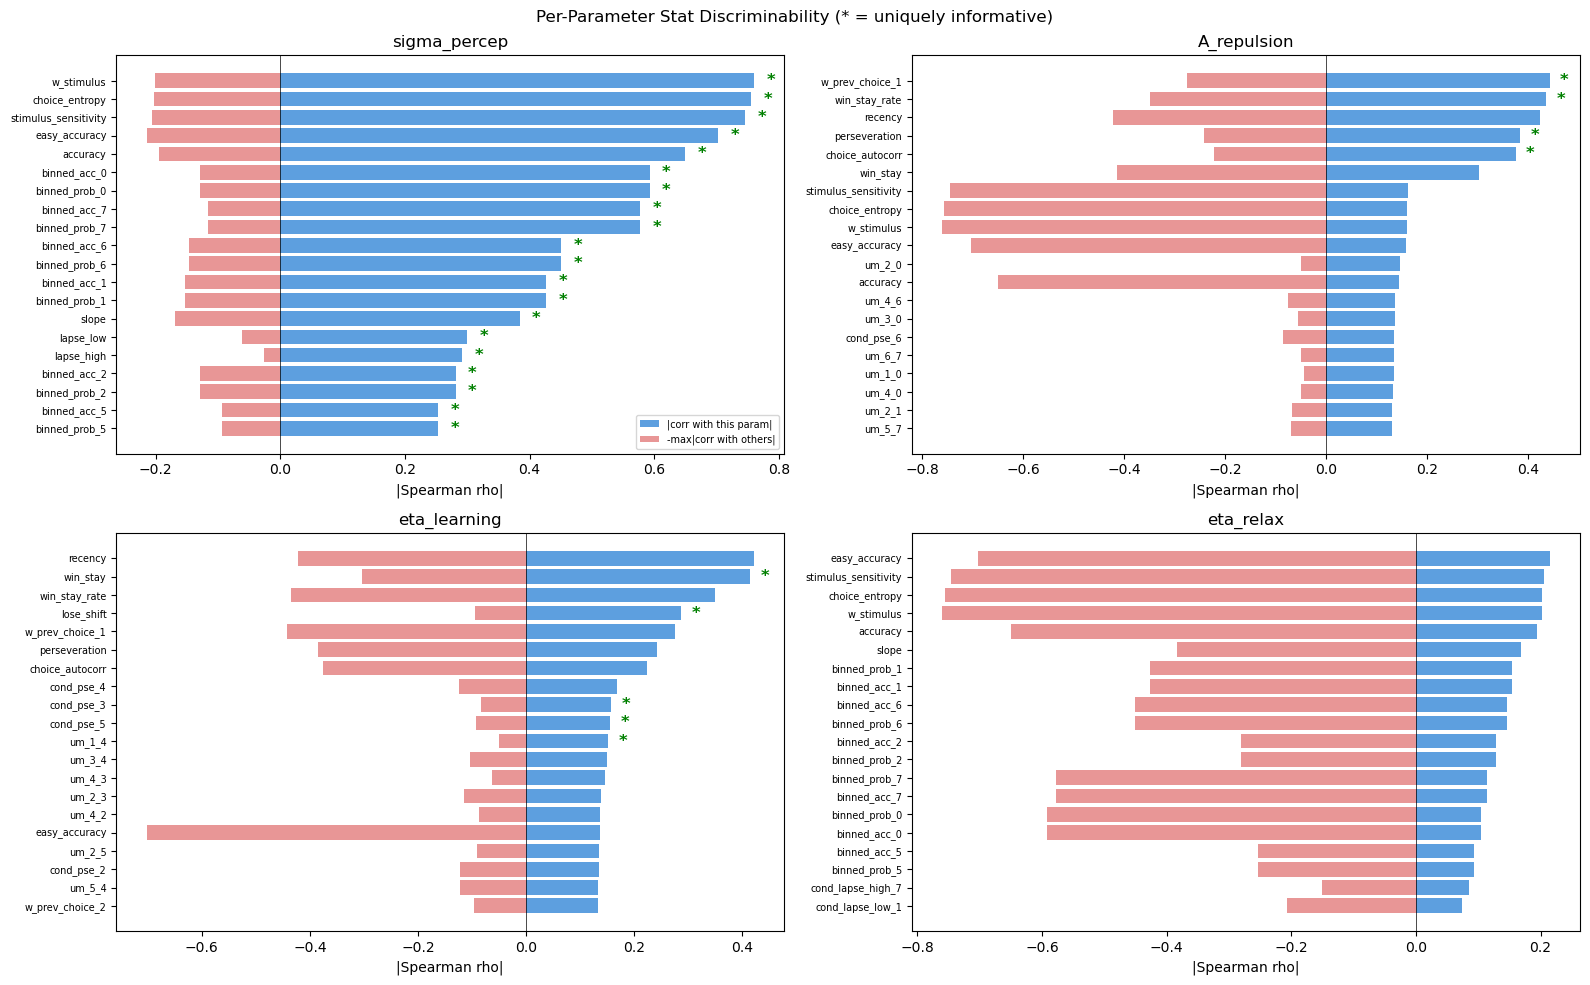

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for p, (ax, pname) in enumerate(zip(axes.flat, PARAM_NAMES)):
    abs_this = np.abs(param_stat_corr[p, :])
    other_mask = np.ones(4, dtype=bool)
    other_mask[p] = False
    abs_others = np.max(np.abs(param_stat_corr[other_mask, :]), axis=0)
    uniqueness = abs_this - abs_others
    
    order = np.argsort(abs_this)[::-1][:20]
    names = [expanded_names[i] for i in order]
    y = np.arange(len(order))
    
    ax.barh(y, abs_this[order], color='#1976d2', alpha=0.7, label='|corr with this param|')
    ax.barh(y, -abs_others[order], color='#d32f2f', alpha=0.5, label='-max|corr with others|')
    
    for i, idx in enumerate(order):
        if uniqueness[idx] > 0.05 and abs_this[idx] > 0.15:
            ax.text(abs_this[idx] + 0.02, i, '*', fontsize=12, fontweight='bold',
                   color='green', va='center')
    
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=7)
    ax.set_xlabel('|Spearman rho|')
    ax.set_title(pname)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.invert_yaxis()
    if p == 0:
        ax.legend(fontsize=7)

fig.suptitle('Per-Parameter Stat Discriminability (* = uniquely informative)', fontsize=12)
plt.tight_layout()
plt.show()

## Part B: Multi-Session Trajectory Sensitivity

Generate synthetic animals with declining eta trajectories. For each
session, compute stats. Ask: which stats track learning (session index)
and which correlate directly with true eta?

In [8]:
# --- Configuration ---
N_ANIMALS = 12
N_SESSIONS_TRAJ = 25
N_TRIALS_TRAJ = 300
SEED_B = 123

In [9]:
# --- Generate animals and compute per-session stats ---
rng_master = np.random.default_rng(SEED_B)

all_stats = []
all_sess_idx = []
all_eta = []
per_animal_corrs = np.empty((N_ANIMALS, n_stats))

print(f"Generating {N_ANIMALS} animals ({N_SESSIONS_TRAJ} sessions each)...")
t0 = time.time()

for a in range(N_ANIMALS):
    if a % 4 == 0:
        print(f"  Animal {a}/{N_ANIMALS}")
    
    animal_seed = int(rng_master.integers(0, 2**31))
    
    # Vary trajectory across animals
    eta_start = rng_master.uniform(0.35, 0.55)
    eta_end = rng_master.uniform(0.06, 0.12)
    decay_rate = rng_master.uniform(0.08, 0.20)
    sigma_percep = rng_master.uniform(0.10, 0.22)
    A_repulsion = rng_master.uniform(0.05, 0.20)
    
    params = param_trajectory_naive_to_expert(
        N_SESSIONS_TRAJ, eta_start=eta_start, eta_end=eta_end,
        decay_rate=decay_rate, sigma_percep=sigma_percep, A_repulsion=A_repulsion,
    )
    
    animal, gt = generate_synthetic_animal(
        animal_id=f'SYN_{a:02d}', true_params=params,
        trials_per_session=N_TRIALS_TRAJ, seed=animal_seed,
    )
    
    eta_traj = gt['params_per_session']['eta_learning']
    animal_stats = np.empty((N_SESSIONS_TRAJ, n_stats))
    
    for s_idx, session in enumerate(animal.sessions):
        arrays = session.trials.get_model_arrays(exclude_abort=True, exclude_opto=True)
        try:
            stats = compute_summary_stats(
                arrays['choices'], arrays['stimuli'], arrays['categories'],
                stat_names=ALL_STATS, return_dict=False,
            )
            animal_stats[s_idx] = stats if len(stats) == n_stats else np.nan
        except Exception:
            animal_stats[s_idx] = np.nan
        
        all_stats.append(animal_stats[s_idx])
        all_sess_idx.append(s_idx)
        all_eta.append(eta_traj[s_idx])
    
    # Per-animal: stat vs session_idx correlation
    sess_arr = np.arange(N_SESSIONS_TRAJ, dtype=float)
    for s in range(n_stats):
        sv = animal_stats[:, s]
        vm = ~np.isnan(sv)
        if vm.sum() >= 5:
            rho, _ = spearmanr(sess_arr[vm], sv[vm])
            per_animal_corrs[a, s] = rho
        else:
            per_animal_corrs[a, s] = np.nan

all_stats = np.array(all_stats)
all_eta = np.array(all_eta)
all_sess_idx = np.array(all_sess_idx)

# Stat-eta direct correlation (pooled)
stat_eta_corr = np.empty(n_stats)
for s in range(n_stats):
    sv = all_stats[:, s]
    vm = ~np.isnan(sv)
    if vm.sum() >= 30:
        rho, _ = spearmanr(all_eta[vm], sv[vm])
        stat_eta_corr[s] = rho
    else:
        stat_eta_corr[s] = np.nan

median_sess_corr = np.nanmedian(per_animal_corrs, axis=0)
print(f"Done in {time.time()-t0:.1f}s")

Generating 12 animals (25 sessions each)...
  Animal 0/12
  Animal 4/12
  Animal 8/12
Done in 17.5s


### Which stats track learning across sessions?

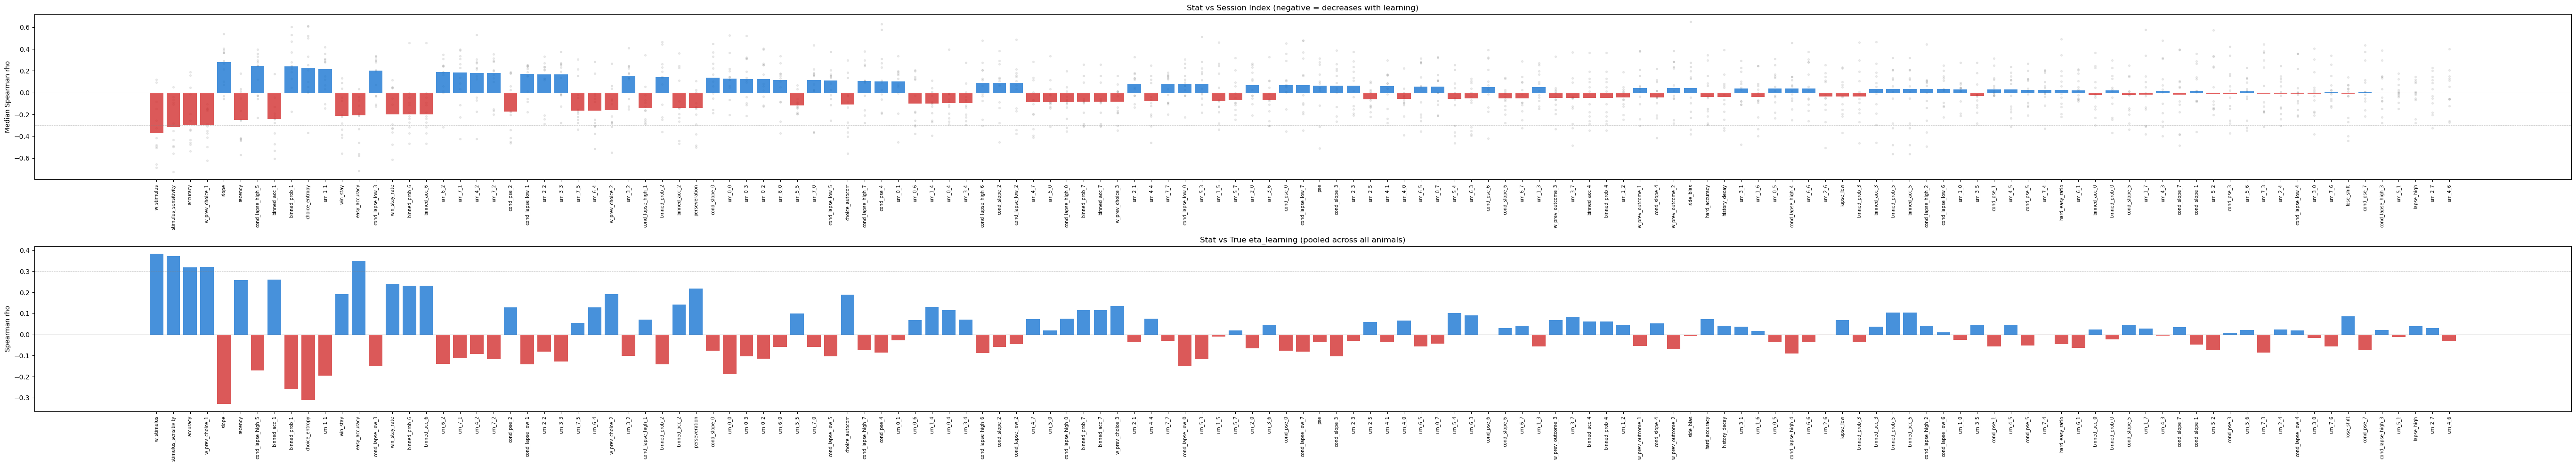

In [10]:
# --- Bar plots: stat vs session_idx, stat vs eta ---
order = np.argsort(np.abs(median_sess_corr))[::-1]

fig, axes = plt.subplots(2, 1, figsize=(max(14, n_stats * 0.4), 10))

# Top: stat vs session index
ax = axes[0]
names_sorted = [expanded_names[i] for i in order]
vals = median_sess_corr[order]

for a in range(N_ANIMALS):
    ax.scatter(range(len(order)), per_animal_corrs[a, order],
               alpha=0.15, s=8, c='grey', zorder=1)

colors = ['#d32f2f' if v < 0 else '#1976d2' for v in vals]
ax.bar(range(len(vals)), vals, color=colors, alpha=0.8, zorder=2)
ax.set_xticks(range(len(names_sorted)))
ax.set_xticklabels(names_sorted, rotation=90, fontsize=7)
ax.set_ylabel('Median Spearman rho')
ax.set_title('Stat vs Session Index (negative = decreases with learning)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(-0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

# Bottom: stat vs true eta
ax = axes[1]
vals_eta = stat_eta_corr[order]
colors_eta = ['#d32f2f' if v < 0 else '#1976d2' for v in vals_eta]
ax.bar(range(len(vals_eta)), vals_eta, color=colors_eta, alpha=0.8)
ax.set_xticks(range(len(names_sorted)))
ax.set_xticklabels(names_sorted, rotation=90, fontsize=7)
ax.set_ylabel('Spearman rho')
ax.set_title('Stat vs True eta_learning (pooled across all animals)')
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axhline(-0.3, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Combined Summary Table

In [11]:
# --- Summary table ---
print("=" * 110)
print("STAT USEFULNESS RANKING (sorted by |eta_learning correlation|)")
print("=" * 110)
print(f"{'Stat':<22s} {'Best param':<14s} {'rho':<7s} {'eta_corr':<9s} "
      f"{'sess_rho':<9s} {'eta_dir':<8s} {'redundancy':<10s}")
print("-" * 110)

rows = []
for s in range(n_stats):
    max_param_corr = np.nanmax(np.abs(param_stat_corr[:, s]))
    best_p = np.nanargmax(np.abs(param_stat_corr[:, s]))
    eta_corr = param_stat_corr[2, s]  # eta_learning = index 2
    inter = np.nanmean(np.abs(stat_stat_corr[s, :]))
    
    rows.append((
        expanded_names[s], PARAM_NAMES[best_p], param_stat_corr[best_p, s],
        eta_corr, median_sess_corr[s], stat_eta_corr[s], inter
    ))

rows.sort(key=lambda r: abs(r[5]) if not np.isnan(r[5]) else 0, reverse=True)

for name, bp, bp_rho, ec, sc, ed, inter in rows:
    flag = ''
    if abs(ed) > 0.3:
        flag = '<-- GOOD for eta'
    elif abs(bp_rho) > 0.3 and abs(ec) < 0.15:
        flag = f'<-- GOOD for {bp}'
    print(f"{name:<22s} {bp:<14s} {bp_rho:+.3f}  {ec:+.3f}    {sc:+.3f}    {ed:+.3f}   "
          f"{inter:.3f}     {flag}")

print("=" * 110)
print()
print("Columns:")
print("  Best param  = parameter with strongest single-session correlation")
print("  rho         = Spearman correlation with that parameter")
print("  eta_corr    = Part A: single-session correlation with eta_learning")
print("  sess_rho    = Part B: median within-animal correlation with session index")
print("  eta_dir     = Part B: direct correlation with true eta (pooled)")
print("  redundancy  = mean |inter-stat correlation| (high = redundant)")

STAT USEFULNESS RANKING (sorted by |eta_learning correlation|)
Stat                   Best param     rho     eta_corr  sess_rho  eta_dir  redundancy
--------------------------------------------------------------------------------------------------------------
w_stimulus             sigma_percep   -0.760  +0.132    -0.369    +0.384   0.160     <-- GOOD for eta
stimulus_sensitivity   sigma_percep   -0.746  +0.123    -0.315    +0.371   0.158     <-- GOOD for eta
easy_accuracy          sigma_percep   -0.702  +0.136    -0.210    +0.350   0.151     <-- GOOD for eta
slope                  sigma_percep   +0.384  -0.103    +0.280    -0.329   0.112     <-- GOOD for eta
w_prev_choice_1        A_repulsion    -0.442  +0.275    -0.295    +0.321   0.107     <-- GOOD for eta
accuracy               sigma_percep   -0.650  +0.117    -0.298    +0.319   0.151     <-- GOOD for eta
choice_entropy         sigma_percep   +0.756  -0.125    +0.229    -0.312   0.161     <-- GOOD for eta
binned_acc_1           sig

### Interpretation notes

**Read the table as follows:**
- Stats with high `eta_dir` are good candidates for SBI (they carry info about learning rate)
- Stats with high `redundancy` can probably be dropped if a correlated stat is already included
- Stats labelled "GOOD for sigma_percep" etc help identify that parameter but not eta
- `eta_relax` is essentially invisible to all stats — it needs temporal structure (multi-session GP prior) to be constrained

**Suggested stat set for SBI** (based on these results):
- `accuracy` — sigma_percep signal, some eta tracking
- `psychometric` (PSE, slope, lapses) — sigma_percep + boundary estimate
- `recency` — A_repulsion + some eta signal
- `win_stay` — best single-stat eta correlate
- `logistic_history` (w_prev_choice_1) — joint A_repulsion/eta signal
- Consider adding `stimulus_sensitivity` for additional eta tracking

---

## Part C: Real Data Validation

Compare summary stat behaviour between synthetic simulations (Part A/B) and real behavioural data.

Key questions:
1. **Stat × session correlation**: Which stats track learning over sessions in real data? (compare with Part B synthetic η correlation)
2. **Inter-stat redundancy**: Is the correlation structure between stats the same in real vs synthetic data?
3. **Stat ranges**: Are real data stat values in the same range as synthetic? If not, prior bounds may be wrong.

Stats that correlate with session index in real data AND with η in synthetic data are the strongest candidates for SBI.

In [12]:
# =============================================================================
# PART C SETUP: Load real data
# =============================================================================
#
# THREE OPTIONS — uncomment the one that matches your setup:
#
# Option 1: Standard directory tree
#   Processed/SS05/SESSION_DIR/trial_summary_*.csv
#   -> load_experiment auto-discovers everything
#
# Option 2: Per-animal directory
#   /path/to/SS05/ containing session subdirs with CSVs
#   -> load_animal for each
#
# Option 3: Explicit CSV paths
#   You have a list/dict of CSV file paths
#   -> load_session_csv for each
# =============================================================================

STAGE = 'Full_Task_Cont'  # stage filter (set to None to include all)

# --- Option 1: load_experiment (standard tree) ---
path = '/Users/Serkan/Desktop/pro/PhD/main/data/Head_Fixed_Behavior/Processed'
experiment = load_experiment(Path(path))

# --- Option 2: load_animal (per-animal directory) ---
# experiment = ExperimentData()
# for aid, path in [('SS05', '/path/to/SS05'), ('SS06', '/path/to/SS06')]:
#     experiment.add_animal(load_animal(aid, path))

# --- Option 3: explicit CSV paths (most flexible) ---

# csv_paths = {
#     'SS05': sorted(Path('/Head_Fixed_Behavior/Processed/SS05').rglob('trial_summary_*.csv')),
#     # 'SS06': sorted(Path('/path/to/SS06').rglob('trial_summary_*.csv')),
# }

# experiment = ExperimentData()
# for aid, paths in csv_paths.items():
#     sessions = []
#     for idx, p in enumerate(paths):
#         try:
#             sess = load_session_csv(p, session_idx=idx)
#             sessions.append(sess)
#         except Exception as e:
#             print(f'  Skip {p.name}: {e}')
#     if sessions:
#         experiment.add_animal(AnimalData(animal_id=aid, sessions=sessions))
#         print(f'{aid}: loaded {len(sessions)} sessions from {len(paths)} CSVs')

# --- Summary ---
print(f'\nLoaded {experiment.n_animals} animals: {experiment.animal_ids}')
for aid in experiment.animal_ids:
    animal = experiment.get_animal(aid)
    if STAGE:
        n_task = len(animal.get_sessions(stage=STAGE))
        print(f'  {aid}: {animal.n_sessions} total, {n_task} {STAGE}')
    else:
        print(f'  {aid}: {animal.n_sessions} sessions')



Loaded 12 animals: ['SS01', 'SS02', 'SS04', 'SS05', 'SS06', 'SS07', 'SS08', 'SS09', 'SS10', 'SS11', 'SS12', 'SS13']
  SS01: 29 total, 27 Full_Task_Cont
  SS02: 14 total, 4 Full_Task_Cont
  SS04: 41 total, 35 Full_Task_Cont
  SS05: 18 total, 18 Full_Task_Cont
  SS06: 18 total, 18 Full_Task_Cont
  SS07: 18 total, 18 Full_Task_Cont
  SS08: 18 total, 18 Full_Task_Cont
  SS09: 9 total, 9 Full_Task_Cont
  SS10: 9 total, 9 Full_Task_Cont
  SS11: 9 total, 9 Full_Task_Cont
  SS12: 9 total, 9 Full_Task_Cont
  SS13: 9 total, 9 Full_Task_Cont


In [13]:
# =============================================================================
# Compute summary stats for each session of each animal
# =============================================================================

real_records = []

for aid in experiment.animal_ids:
    animal = experiment.get_animal(aid)
    sessions = animal.get_sessions(stage=STAGE) if STAGE else animal.sessions
    
    for sess_idx, sess in enumerate(sessions):
        arrays = sess.trials.get_model_arrays(
            exclude_abort=True, exclude_opto=True,
        )
        
        # Filter no-response trials
        valid = ~arrays['no_response']
        if valid.sum() < 30:
            continue
        
        stats = compute_summary_stats(
            arrays['choices'][valid],
            arrays['stimuli'][valid],
            arrays['categories'][valid],
            stat_names=ALL_STATS, return_dict=False,
        )
        
        real_records.append({
            'animal_id': aid,
            'session_idx': sess_idx,
            'session_id': sess.session_id,
            'n_trials': int(valid.sum()),
            'stats': stats,
        })

# Build matrix
real_stat_matrix = np.array([r['stats'] for r in real_records])
real_session_idx = np.array([r['session_idx'] for r in real_records])
real_animal_ids = np.array([r['animal_id'] for r in real_records])
n_features = real_stat_matrix.shape[1]

print(f'Total sessions: {len(real_records)}')
print(f'Stat matrix shape: {real_stat_matrix.shape}')

nan_per_feat = np.sum(np.isnan(real_stat_matrix), axis=0)
if nan_per_feat.sum() > 0:
    print(f'Features with NaN: {(nan_per_feat > 0).sum()}/{n_features}')
    for j in np.where(nan_per_feat > 0)[0]:
        print(f'  {expanded_names[j]}: {nan_per_feat[j]} NaN sessions')
else:
    print('No NaN values.')


Total sessions: 183
Stat matrix shape: (183, 137)
Features with NaN: 48/137
  pse: 25 NaN sessions
  slope: 25 NaN sessions
  win_stay: 1 NaN sessions
  lose_shift: 1 NaN sessions
  cond_pse_0: 2 NaN sessions
  cond_slope_0: 2 NaN sessions
  cond_lapse_low_0: 2 NaN sessions
  cond_lapse_high_0: 2 NaN sessions
  cond_pse_1: 2 NaN sessions
  cond_slope_1: 2 NaN sessions
  cond_lapse_low_1: 2 NaN sessions
  cond_lapse_high_1: 2 NaN sessions
  cond_pse_2: 2 NaN sessions
  cond_slope_2: 2 NaN sessions
  cond_lapse_low_2: 2 NaN sessions
  cond_lapse_high_2: 2 NaN sessions
  cond_pse_3: 2 NaN sessions
  cond_slope_3: 2 NaN sessions
  cond_lapse_low_3: 2 NaN sessions
  cond_lapse_high_3: 2 NaN sessions
  cond_pse_4: 2 NaN sessions
  cond_slope_4: 2 NaN sessions
  cond_lapse_low_4: 2 NaN sessions
  cond_lapse_high_4: 2 NaN sessions
  cond_pse_5: 2 NaN sessions
  cond_slope_5: 2 NaN sessions
  cond_lapse_low_5: 2 NaN sessions
  cond_lapse_high_5: 2 NaN sessions
  cond_pse_6: 2 NaN sessions
  con

### C.1: Stat × Session Index Correlation

Which stats change systematically over training? Stats that correlate with session index
in real data are candidates for tracking the naive→expert transition.

Computed per-animal (to avoid pooling artifacts), then averaged.

In [14]:
animal = experiment.get_animal('SS01')
sess = animal.get_sessions(stage=STAGE)[0]  # is this the same session?
arrays = sess.trials.get_model_arrays(exclude_abort=True, exclude_opto=True)
valid = ~arrays['no_response']
print(f"Raw trials: {sess.trials.n_trials}")
print(f"After get_model_arrays: {len(arrays['stimuli'])}")
print(f"After no_response filter: {valid.sum()}")
print(f"Session: {sess.session_id}, date: {sess.date}")

Raw trials: 594
After get_model_arrays: 556
After no_response filter: 556
Session: SOUND_CAT_SS01_2026_1_12, date: 2026-01-12


In [15]:
# =============================================================================
# C.1: Per-animal Spearman correlation: stat vs session_idx
# =============================================================================

unique_animals = np.unique(real_animal_ids)
n_animals = len(unique_animals)

# Per-animal correlations
per_animal_corrs = np.full((n_animals, n_features), np.nan)

for a_idx, aid in enumerate(unique_animals):
    mask = real_animal_ids == aid
    stats_a = real_stat_matrix[mask]
    sess_a = real_session_idx[mask]
    
    if len(sess_a) < 5:
        continue  # too few sessions
    
    for f_idx in range(n_features):
        vals = stats_a[:, f_idx]
        valid = ~np.isnan(vals)
        if valid.sum() >= 5:
            rho, _ = spearmanr(sess_a[valid], vals[valid])
            per_animal_corrs[a_idx, f_idx] = rho

# Mean across animals
mean_sess_corr = np.nanmean(per_animal_corrs, axis=0)

# Print top trackers
order = np.argsort(np.abs(mean_sess_corr))[::-1]
print('Top 25 stats correlated with session index (real data):')
print(f'{"Stat":35s} {"mean |rho|":>10s}  {"mean rho":>10s}  per-animal rhos')
print('-' * 100)
for rank, idx in enumerate(order[:25]):
    rhos = per_animal_corrs[:, idx]
    valid_rhos = rhos[~np.isnan(rhos)]
    rho_strs = ', '.join([f'{r:.2f}' for r in valid_rhos])
    print(f'{expanded_names[idx]:35s} {np.abs(mean_sess_corr[idx]):10.3f}  {mean_sess_corr[idx]:10.3f}  [{rho_strs}]')


Top 25 stats correlated with session index (real data):
Stat                                mean |rho|    mean rho  per-animal rhos
----------------------------------------------------------------------------------------------------
easy_accuracy                            0.484       0.484  [0.20, -0.29, 0.81, -0.28, 0.92, 0.57, 0.88, 0.58, 0.70, 0.97, 0.25]
stimulus_sensitivity                     0.484       0.484  [0.29, -0.22, 0.80, -0.33, 0.94, 0.67, 0.83, 0.38, 0.75, 0.98, 0.20]
binned_prob_0                            0.456      -0.456  [-0.37, -0.02, -0.32, -0.42, -0.90, -0.24, -0.92, 0.30, -0.68, -0.83, -0.61]
binned_acc_0                             0.456       0.456  [0.37, 0.02, 0.32, 0.42, 0.90, 0.24, 0.92, -0.30, 0.68, 0.83, 0.61]
cond_lapse_low_0                         0.436      -0.436  [-0.24, 0.04, -0.42, -0.53, -0.88, -0.50, -0.79, -0.32, -0.56, -0.67, 0.07]
w_stimulus                               0.432       0.432  [0.33, -0.09, 0.85, -0.23, 0.90, 0.42, 0.37, 0.0

### C.2: Synthetic vs Real Session-Tracking Comparison

Scatter plot: x = synthetic η correlation (from Part B), y = real session-index correlation.

Stats in the **upper-right or lower-left quadrant** (same sign, both strong) are the best
candidates — they track learning in both simulated and real data.

Stats with high synthetic but low real correlation may indicate model-data mismatch.

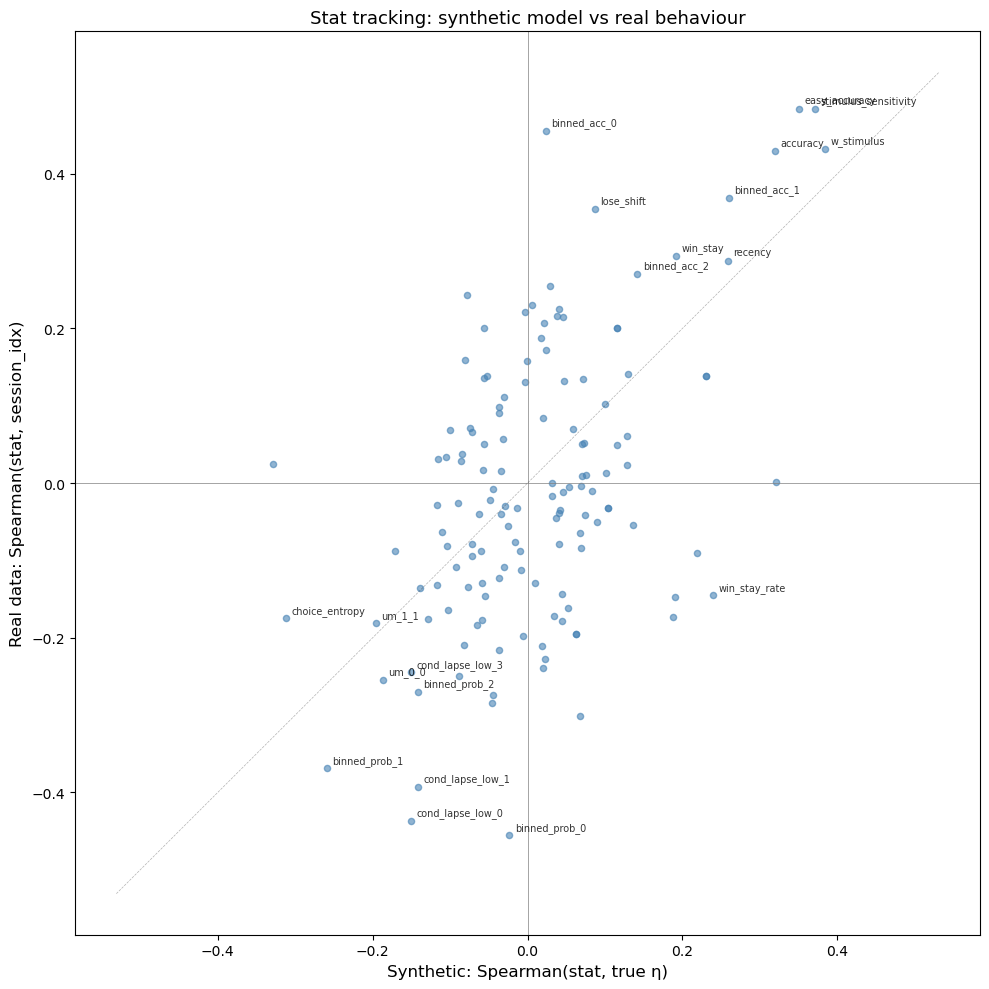


Correlation between synthetic and real tracking: rho=0.400, p=1.32e-06


In [16]:
# =============================================================================
# C.2: Scatter — synthetic eta_corr vs real session_idx_corr
# =============================================================================

# 'stat_eta_corr' was computed in Part B (Spearman: stat vs true eta_learning)
# If Part B wasn't run, recompute or skip
try:
    synth_eta_corr = stat_eta_corr  # from Part B
except NameError:
    print('Part B results not in memory — run Part B first or load from saved results.')
    synth_eta_corr = None

if synth_eta_corr is not None:
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.scatter(synth_eta_corr, mean_sess_corr, s=20, alpha=0.6, c='steelblue')
    
    # Label top stats (high combined rank)
    combined_strength = np.abs(synth_eta_corr) + np.abs(mean_sess_corr)
    top_n = 20
    top_idx = np.argsort(combined_strength)[-top_n:]
    
    for idx in top_idx:
        ax.annotate(
            expanded_names[idx],
            (synth_eta_corr[idx], mean_sess_corr[idx]),
            fontsize=7, alpha=0.8,
            xytext=(4, 4), textcoords='offset points',
        )
    
    # Quadrant lines
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    
    # Diagonal
    lim = max(np.abs(ax.get_xlim()).max(), np.abs(ax.get_ylim()).max())
    ax.plot([-lim, lim], [-lim, lim], 'k--', alpha=0.3, linewidth=0.5)
    
    ax.set_xlabel('Synthetic: Spearman(stat, true η)', fontsize=12)
    ax.set_ylabel('Real data: Spearman(stat, session_idx)', fontsize=12)
    ax.set_title('Stat tracking: synthetic model vs real behaviour', fontsize=13)

    
    plt.tight_layout()
    plt.show()
    
    # Correlation between the two
    valid = ~(np.isnan(synth_eta_corr) | np.isnan(mean_sess_corr))
    rho, p = spearmanr(synth_eta_corr[valid], mean_sess_corr[valid])
    print(f'\nCorrelation between synthetic and real tracking: rho={rho:.3f}, p={p:.2e}')


### C.3: Inter-Stat Redundancy — Real vs Synthetic

Compare the stat×stat correlation matrices. If the structure matches, the BE model
captures the real dependencies between behavioural features. Large mismatches suggest
the model is missing behavioural structure.

Features with <20% NaN: 137/137


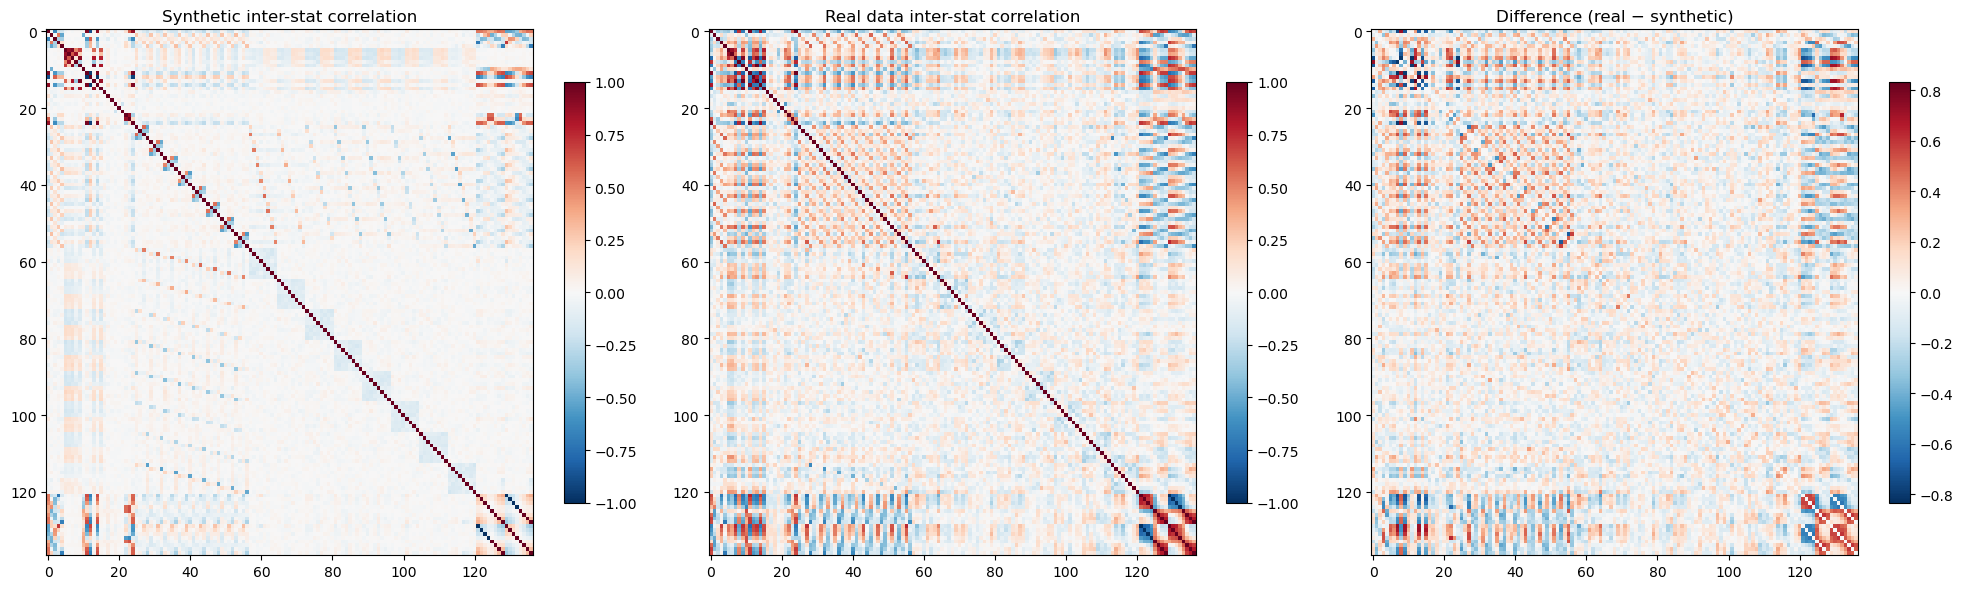

Correlation between real and synthetic inter-stat matrices: rho=0.419, p=0.00e+00
  (on 18632 pairs)


In [17]:
# =============================================================================
# C.3: Inter-stat correlation — real vs synthetic
# =============================================================================

# Real data inter-stat correlation
# Use only features with <20% NaN
nan_rate = np.mean(np.isnan(real_stat_matrix), axis=0)
good_feats = nan_rate < 0.2
print(f'Features with <20% NaN: {good_feats.sum()}/{n_features}')

real_corr = np.full((n_features, n_features), np.nan)
for i in range(n_features):
    if not good_feats[i]:
        continue
    for j in range(i, n_features):
        if not good_feats[j]:
            continue
        valid = ~(np.isnan(real_stat_matrix[:, i]) | np.isnan(real_stat_matrix[:, j]))
        if valid.sum() >= 10:
            rho, _ = spearmanr(real_stat_matrix[valid, i], real_stat_matrix[valid, j])
            real_corr[i, j] = rho
            real_corr[j, i] = rho

# Synthetic inter-stat correlation (from Part A: stat_values matrix)
try:
    synth_corr = np.corrcoef(stat_values.T)  # from Part A
except NameError:
    print('Part A stat_values not in memory — run Part A first.')
    synth_corr = None

if synth_corr is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Synthetic
    im0 = axes[0].imshow(synth_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_title('Synthetic inter-stat correlation')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    
    # Real
    im1 = axes[1].imshow(real_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    axes[1].set_title('Real data inter-stat correlation')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    
    # Difference
    diff = real_corr - synth_corr
    vmax_d = np.nanmax(np.abs(diff))
    im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d, aspect='auto')
    axes[2].set_title('Difference (real − synthetic)')
    plt.colorbar(im2, ax=axes[2], shrink=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # Summary: element-wise correlation between the two matrices
    mask = ~(np.isnan(real_corr) | np.isnan(synth_corr))
    # Exclude diagonal
    np.fill_diagonal(mask, False)
    if mask.sum() > 10:
        rho, p = spearmanr(real_corr[mask], synth_corr[mask])
        print(f'Correlation between real and synthetic inter-stat matrices: rho={rho:.3f}, p={p:.2e}')
        print(f'  (on {mask.sum()} pairs)')


### C.4: Stat Range Comparison

Are real data stat values within the range produced by the synthetic model?
If real values fall outside the synthetic prior predictive range, the prior bounds
or model structure may need adjustment.

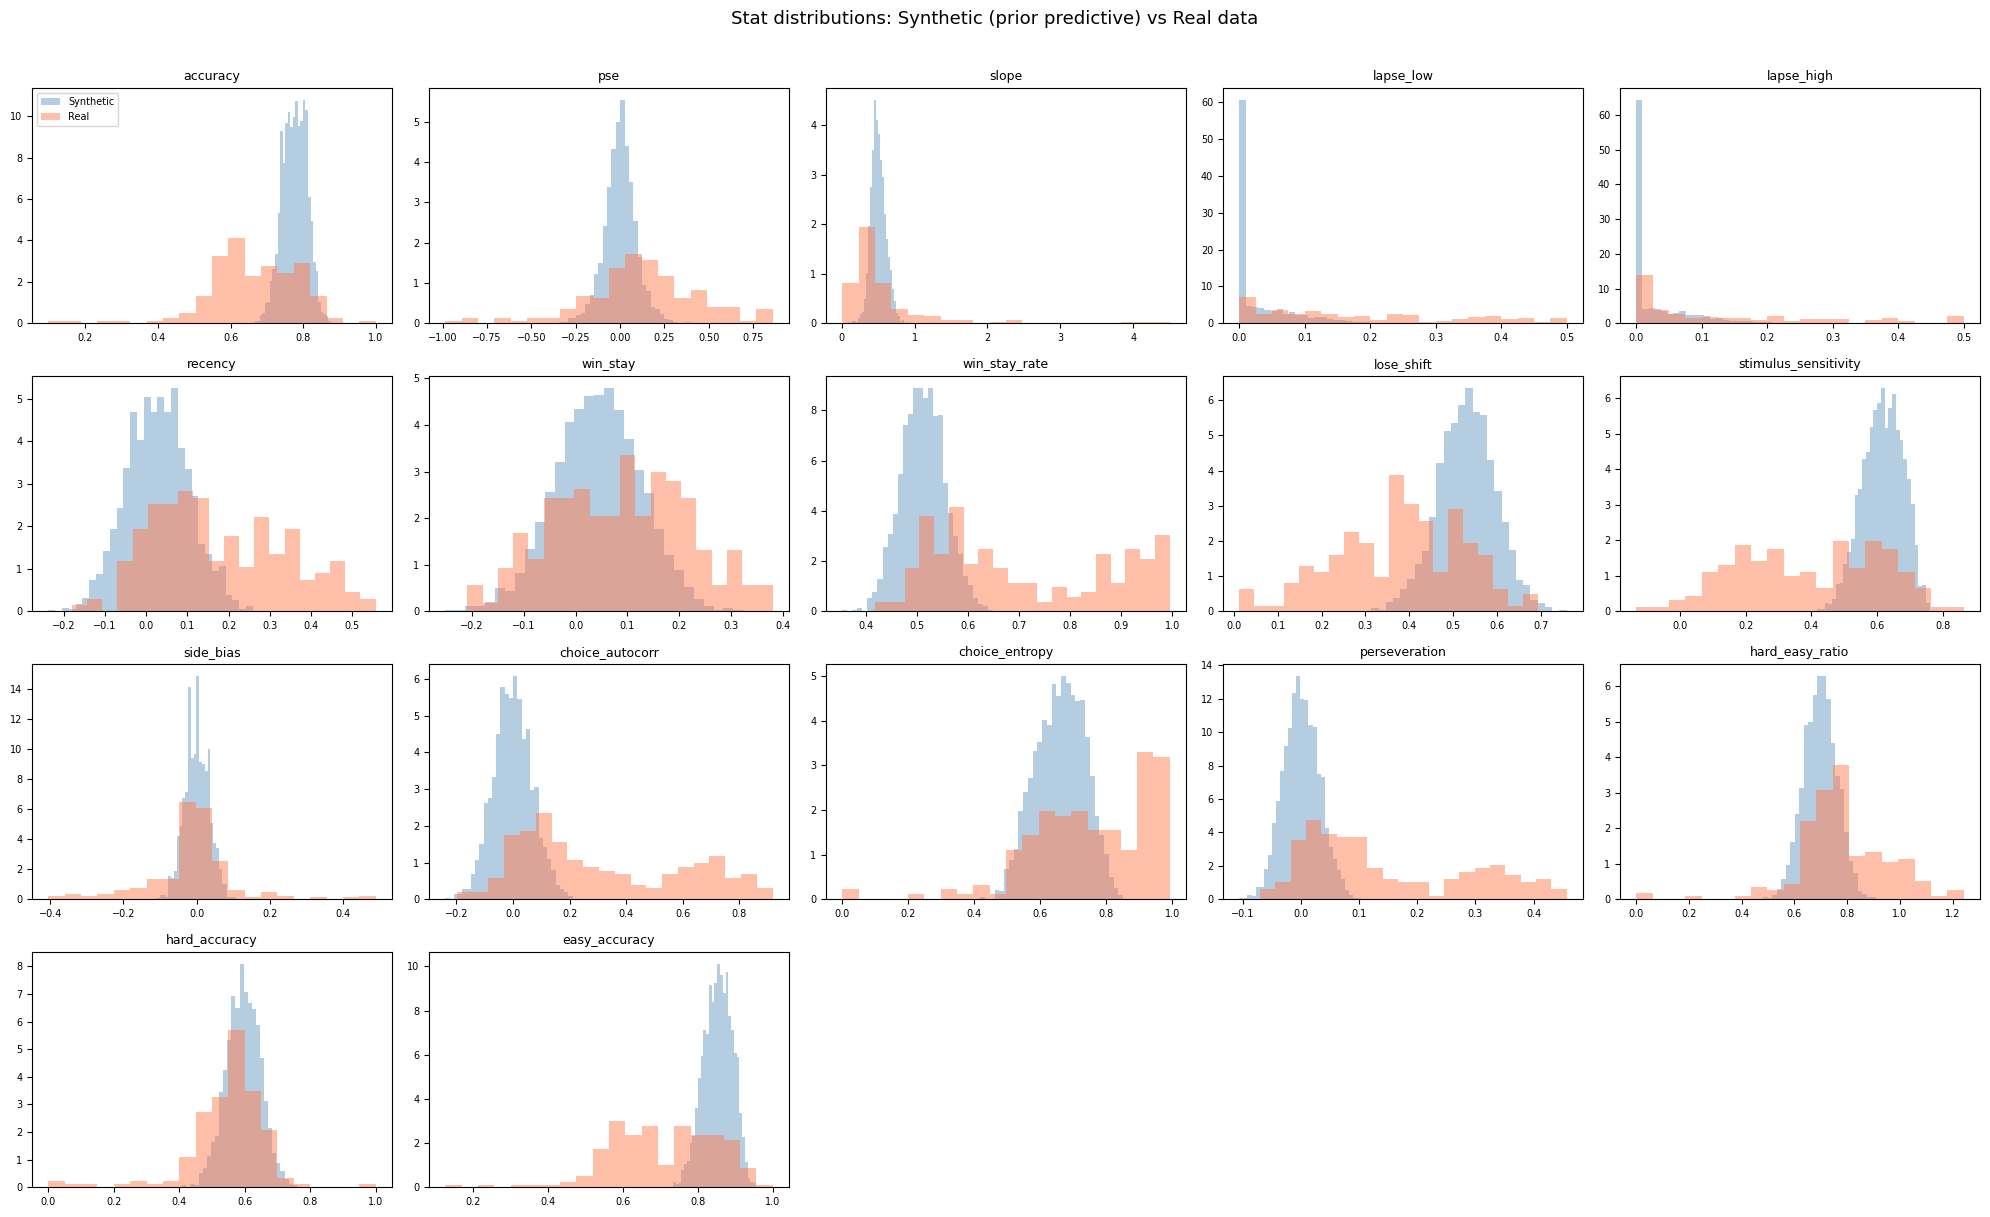


Out-of-range check (real median outside synthetic 5th-95th percentile):
  ⚠ accuracy                      : real median=0.660, synth [5%-95%]=[0.720, 0.830]
  ⚠ win_stay_rate                 : real median=0.650, synth [5%-95%]=[0.441, 0.583]
  ⚠ lose_shift                    : real median=0.385, synth [5%-95%]=[0.421, 0.636]
  ⚠ stimulus_sensitivity          : real median=0.393, synth [5%-95%]=[0.513, 0.711]
  ⚠ choice_autocorr               : real median=0.207, synth [5%-95%]=[-0.111, 0.114]
  ⚠ perseveration                 : real median=0.098, synth [5%-95%]=[-0.049, 0.052]
  ⚠ easy_accuracy                 : real median=0.698, synth [5%-95%]=[0.790, 0.913]


In [18]:
# =============================================================================
# C.4: Range comparison — real vs synthetic
# =============================================================================

# Use scalar stats only (skip high-dim ones for readability)
scalar_stats = [
    'accuracy', 'psychometric', 'recency', 'win_stay', 'win_stay_rate',
    'lose_shift', 'stimulus_sensitivity', 'side_bias', 'choice_autocorr',
    'choice_entropy', 'perseveration', 'hard_easy_ratio', 'hard_accuracy',
    'easy_accuracy',
]
scalar_expanded = get_stat_names_expanded(scalar_stats)
scalar_idx = [expanded_names.index(s) for s in scalar_expanded]

try:
    synth_vals = stat_values[:, scalar_idx]  # from Part A
except NameError:
    synth_vals = None

if synth_vals is not None:
    real_vals = real_stat_matrix[:, scalar_idx]
    n_scalars = len(scalar_expanded)
    
    n_cols = 5
    n_rows = int(np.ceil(n_scalars / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    
    for i, name in enumerate(scalar_expanded):
        ax = axes[i]
        
        # Synthetic distribution
        sv = synth_vals[:, i]
        sv = sv[~np.isnan(sv)]
        if len(sv) > 0:
            ax.hist(sv, bins=30, alpha=0.4, color='steelblue', density=True, label='Synthetic')
        
        # Real data distribution
        rv = real_vals[:, i]
        rv = rv[~np.isnan(rv)]
        if len(rv) > 0:
            ax.hist(rv, bins=20, alpha=0.5, color='coral', density=True, label='Real')
        
        ax.set_title(name, fontsize=9)
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.legend(fontsize=7)
    
    # Hide empty subplots
    for i in range(n_scalars, len(axes)):
        axes[i].set_visible(False)
    
    fig.suptitle('Stat distributions: Synthetic (prior predictive) vs Real data', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # Flag stats where real data falls outside synthetic range
    print('\nOut-of-range check (real median outside synthetic 5th-95th percentile):')
    for i, name in enumerate(scalar_expanded):
        rv = real_vals[:, i]
        rv = rv[~np.isnan(rv)]
        sv = synth_vals[:, i]
        sv = sv[~np.isnan(sv)]
        if len(rv) == 0 or len(sv) == 0:
            continue
        real_med = np.median(rv)
        s_lo, s_hi = np.percentile(sv, [5, 95])
        if real_med < s_lo or real_med > s_hi:
            print(f'  ⚠ {name:30s}: real median={real_med:.3f}, synth [5%-95%]=[{s_lo:.3f}, {s_hi:.3f}]')


### C.5: Combined Ranking — Synthetic + Real

Final table merging Part B (synthetic η correlation) with Part C (real session correlation).
Use this to select stats for SBI.

In [19]:
# =============================================================================
# C.5: Combined ranking table
# =============================================================================

try:
    synth_eta = stat_eta_corr
except NameError:
    synth_eta = np.full(n_features, np.nan)

# Combined score: geometric mean of |synth_eta_corr| and |real_sess_corr|
# (rewards stats that are strong in both, penalises stats strong in only one)
abs_synth = np.abs(synth_eta)
abs_real = np.abs(mean_sess_corr)
combined = np.sqrt(abs_synth * abs_real)  # geometric mean

# Agreement sign: do they point the same direction?
same_sign = np.sign(synth_eta) == np.sign(mean_sess_corr)

order = np.argsort(combined)[::-1]

print(f'{"Rank":>4s}  {"Stat":35s} {"synth |ρ(η)|":>12s} {"real |ρ(sess)|":>14s} {"combined":>10s} {"agree":>6s}')
print('=' * 95)
for rank, idx in enumerate(order[:40]):
    agree_str = '✓' if same_sign[idx] else '✗'
    print(f'{rank+1:4d}  {expanded_names[idx]:35s} '
          f'{abs_synth[idx]:12.3f} {abs_real[idx]:14.3f} {combined[idx]:10.3f} {agree_str:>6s}')

# Suggested stat set for SBI
threshold = 0.15
suggested = [expanded_names[i] for i in order if combined[i] > threshold and same_sign[i]]
print(f'\n--- Suggested stats for SBI (combined > {threshold}, signs agree) ---')
print(f'  {len(suggested)} features: {suggested}')

# Map back to stat groups
suggested_groups = set()
for sname in suggested:
    for group in ALL_STATS:
        group_expanded = get_stat_names_expanded([group])
        if sname in group_expanded:
            suggested_groups.add(group)
            break
print(f'  Stat groups: {sorted(suggested_groups)}')


Rank  Stat                                synth |ρ(η)| real |ρ(sess)|   combined  agree
   1  stimulus_sensitivity                       0.371          0.484      0.424      ✓
   2  easy_accuracy                              0.350          0.484      0.412      ✓
   3  w_stimulus                                 0.384          0.432      0.407      ✓
   4  accuracy                                   0.319          0.429      0.370      ✓
   5  binned_prob_1                              0.260          0.369      0.310      ✓
   6  binned_acc_1                               0.260          0.369      0.310      ✓
   7  recency                                    0.258          0.287      0.272      ✓
   8  cond_lapse_low_0                           0.150          0.436      0.256      ✓
   9  win_stay                                   0.192          0.294      0.238      ✓
  10  cond_lapse_low_1                           0.141          0.393      0.236      ✓
  11  choice_entropy            

### Interpretation

**Ideal stat for SBI** has:
- High |ρ| with η in synthetic data (parameter-informative)
- High |ρ| with session index in real data (tracks real learning)
- Same sign in both (model captures the direction of change)
- Low redundancy with other selected stats

**Warning signs:**
- High synthetic but low real correlation → model predicts a pattern that doesn't exist in real behaviour
- High real but low synthetic correlation → real data has structure the BE model doesn't capture (e.g., RT effects, fatigue)
- Opposite signs → model gets the direction of change wrong
- Real values outside synthetic range → prior bounds or model structure needs adjusting

Use the suggested stat set as a starting point for notebook 4 (SBI). You may want to
manually add/remove stats based on domain knowledge.

---
**Next:** `3_hmm_state_discovery.ipynb` — Use HMM to discover behavioural
states in summary stat trajectories